In [77]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost joblib

### Import Libraries

In [78]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

import joblib

In [79]:
df = pd.read_csv("heart_disease.csv")

df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [80]:
print("Dataset Shape:", df.shape)


Dataset Shape: (10000, 21)


In [81]:
print("\nColumns:")
print(df.columns.tolist())



Columns:
['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status']


In [82]:

print("\nData Types:")
print(df.dtypes)


Data Types:
Age                     float64
Gender                   object
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits          object
Smoking                  object
Family Heart Disease     object
Diabetes                 object
BMI                     float64
High Blood Pressure      object
Low HDL Cholesterol      object
High LDL Cholesterol     object
Alcohol Consumption      object
Stress Level             object
Sleep Hours             float64
Sugar Consumption        object
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status     object
dtype: object


In [83]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing %": (missing.values / len(df)) * 100
})

missing_df = missing_df.sort_values(
    "Missing Values",
    ascending=False
)

display(missing_df)

,Column,Missing Values,Missing %
12,Alcohol Consumption,2586,25.86
7,Diabetes,30,0.30
15,Sugar Consumption,30,0.30
3,Cholesterol Level,30,0.30
0,Age,29,0.29
16,Triglyceride Level,26,0.26
18,CRP Level,26,0.26
11,High LDL Cholesterol,26,0.26
9,High Blood Pressure,26,0.26
10,Low HDL Cholesterol,25,0.25


In [84]:
df['Alcohol Consumption'].value_counts(dropna=False)

,count
Alcohol Consumption,
NaN,2586
Medium,2500
Low,2488
High,2426


In [85]:
df['Alcohol Consumption'] = df['Alcohol Consumption'].fillna(
    df['Alcohol Consumption'].mode()[0]
)

In [86]:
print(df.isnull().sum().sort_values(ascending=False))

Cholesterol Level       30
Sugar Consumption       30
Diabetes                30
Age                     29
High LDL Cholesterol    26
Triglyceride Level      26
CRP Level               26
High Blood Pressure     26
Exercise Habits         25
Sleep Hours             25
Smoking                 25
Low HDL Cholesterol     25
Stress Level            22
BMI                     22
Fasting Blood Sugar     22
Family Heart Disease    21
Homocysteine Level      20
Gender                  19
Blood Pressure          19
Alcohol Consumption      0
Heart Disease Status     0
dtype: int64


In [87]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [88]:
TARGET = "Heart Disease Status"

In [89]:
print(df[TARGET].unique())

['No' 'Yes']


In [90]:
print(
    df[TARGET].value_counts()
)

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64


In [91]:
print(
    df[TARGET].value_counts(normalize=True) * 100
)

Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


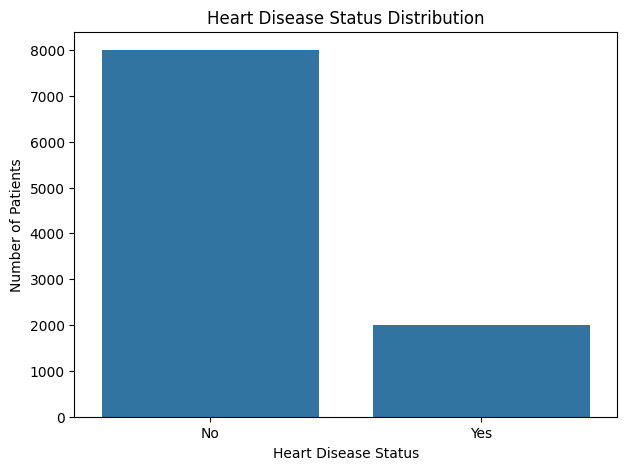

In [92]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Heart Disease Status Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

plt.show()

In [93]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical Columns:")

for col in categorical_columns:
    print("\n", col)
    print(df[col].unique())

Categorical Columns:

 Gender
['Male' 'Female' nan]

 Exercise Habits
['High' 'Low' 'Medium' nan]

 Smoking
['Yes' 'No' nan]

 Family Heart Disease
['Yes' 'No' nan]

 Diabetes
['No' 'Yes' nan]

 High Blood Pressure
['Yes' 'No' nan]

 Low HDL Cholesterol
['Yes' 'No' nan]

 High LDL Cholesterol
['No' 'Yes' nan]

 Alcohol Consumption
['High' 'Medium' 'Low']

 Stress Level
['Medium' 'High' 'Low' nan]

 Sugar Consumption
['Medium' 'Low' 'High' nan]

 Heart Disease Status
['No' 'Yes']


In [94]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical Columns:")

for col in numerical_columns:
    print(col)

Numerical Columns:
Age
Blood Pressure
Cholesterol Level
BMI
Sleep Hours
Triglyceride Level
Fasting Blood Sugar
CRP Level
Homocysteine Level


In [95]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [96]:
df.describe(include="object")

,Gender,Exercise Habits,Smoking,Family Heart Disease,Diabetes,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sugar Consumption,Heart Disease Status
count,9981,9975,9975,9979,9970,9974,9975,9974,10000,9978,9970,10000
unique,2,3,2,2,2,2,2,2,3,3,3,2
top,Male,High,Yes,No,No,Yes,Yes,No,Medium,Medium,Low,No
freq,5003,3372,5123,5004,5018,5022,5000,5036,5086,3387,3390,8000


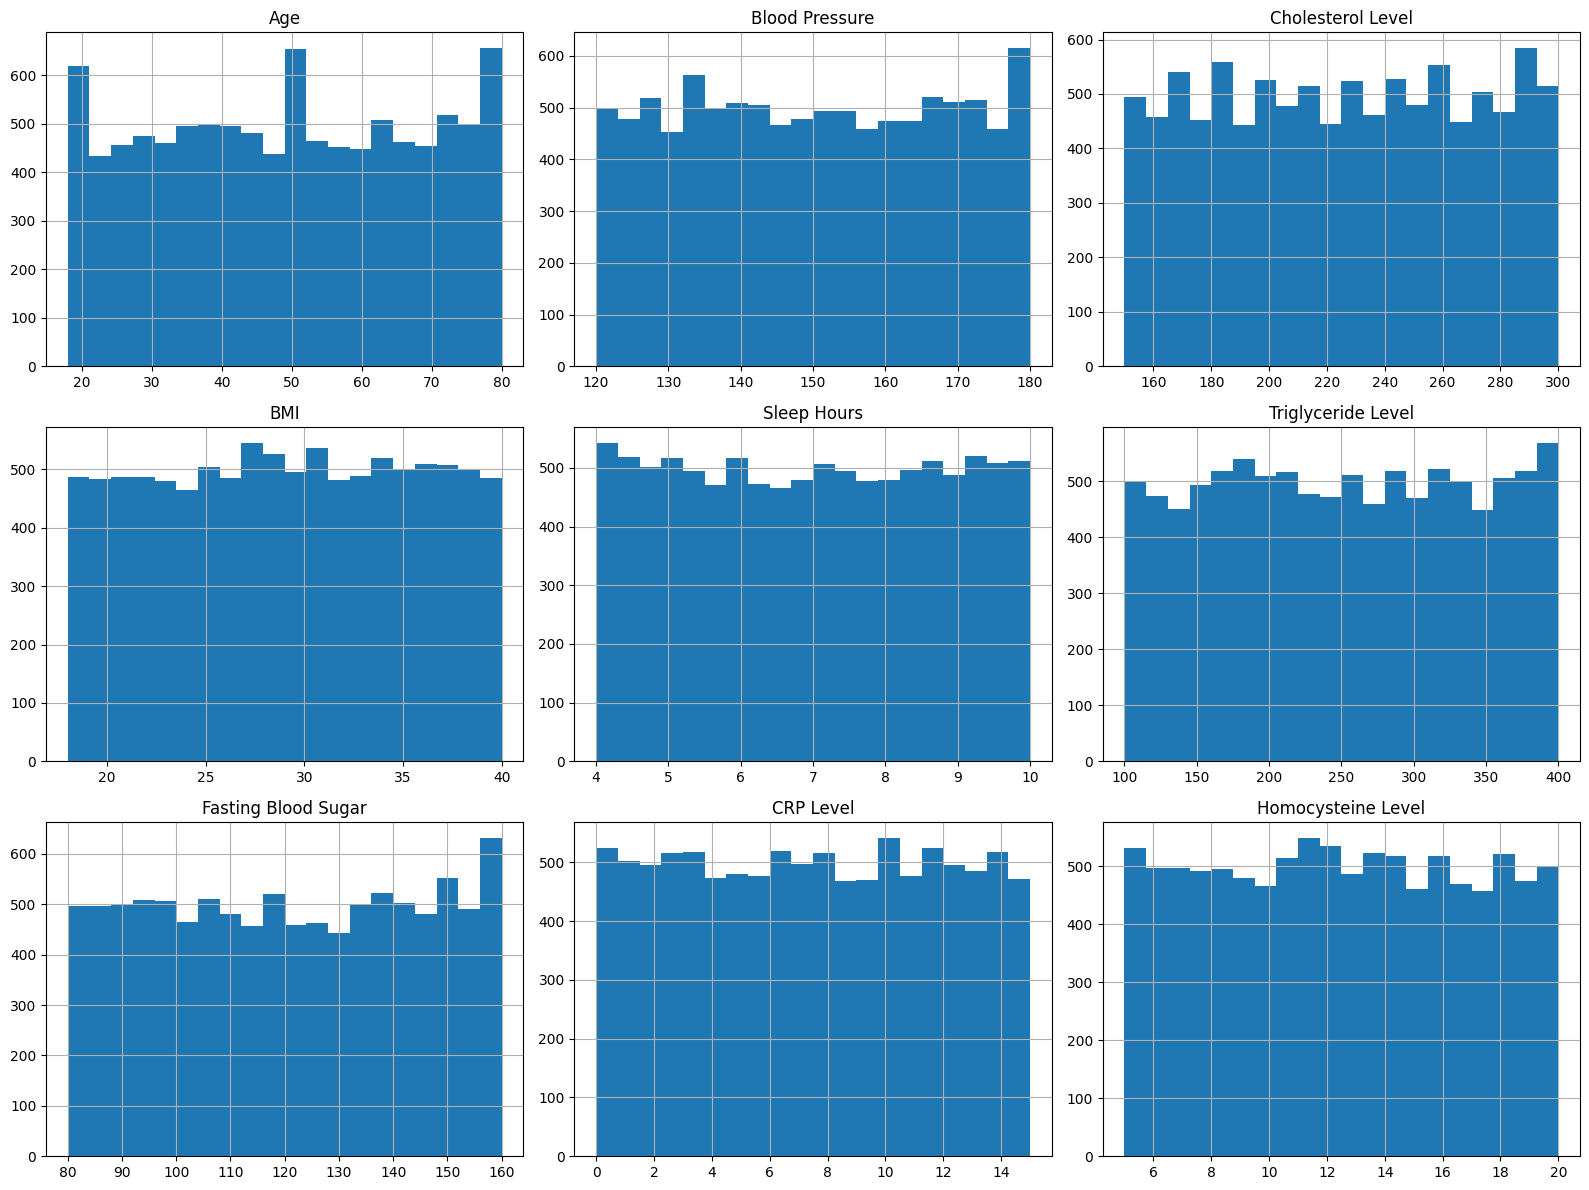

In [97]:
df[numerical_columns].hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()
plt.show()

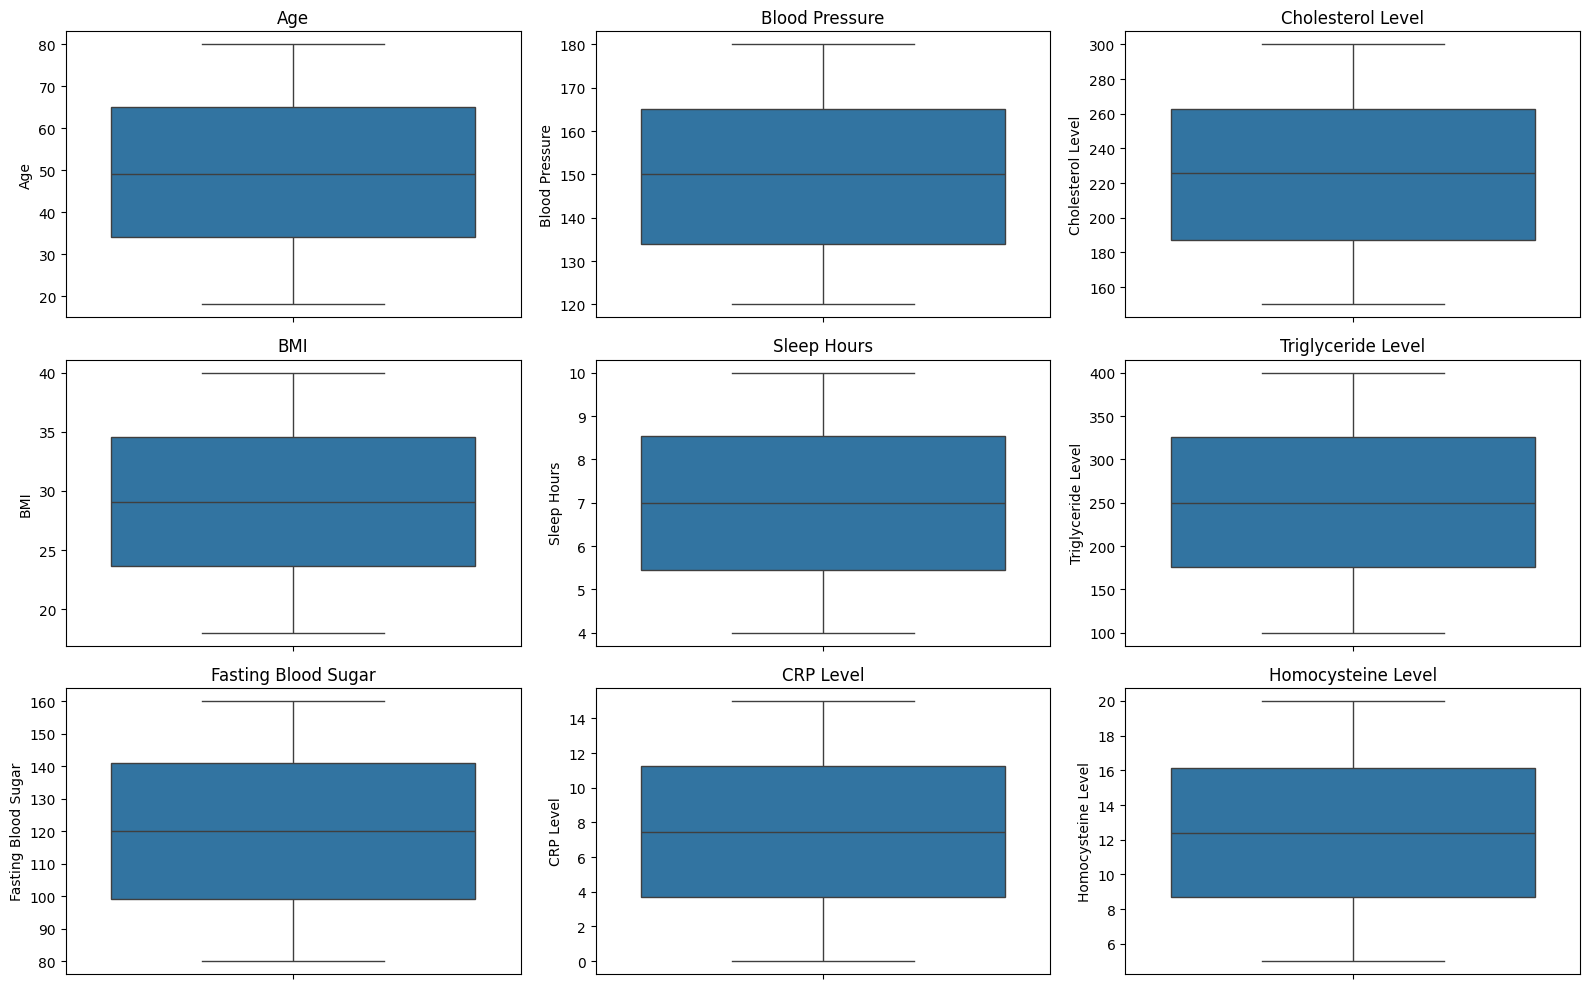

In [98]:
plt.figure(figsize=(16,10))

for i, col in enumerate(numerical_columns, 1):

    plt.subplot(3, 3, i)

    sns.boxplot(
        y=df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

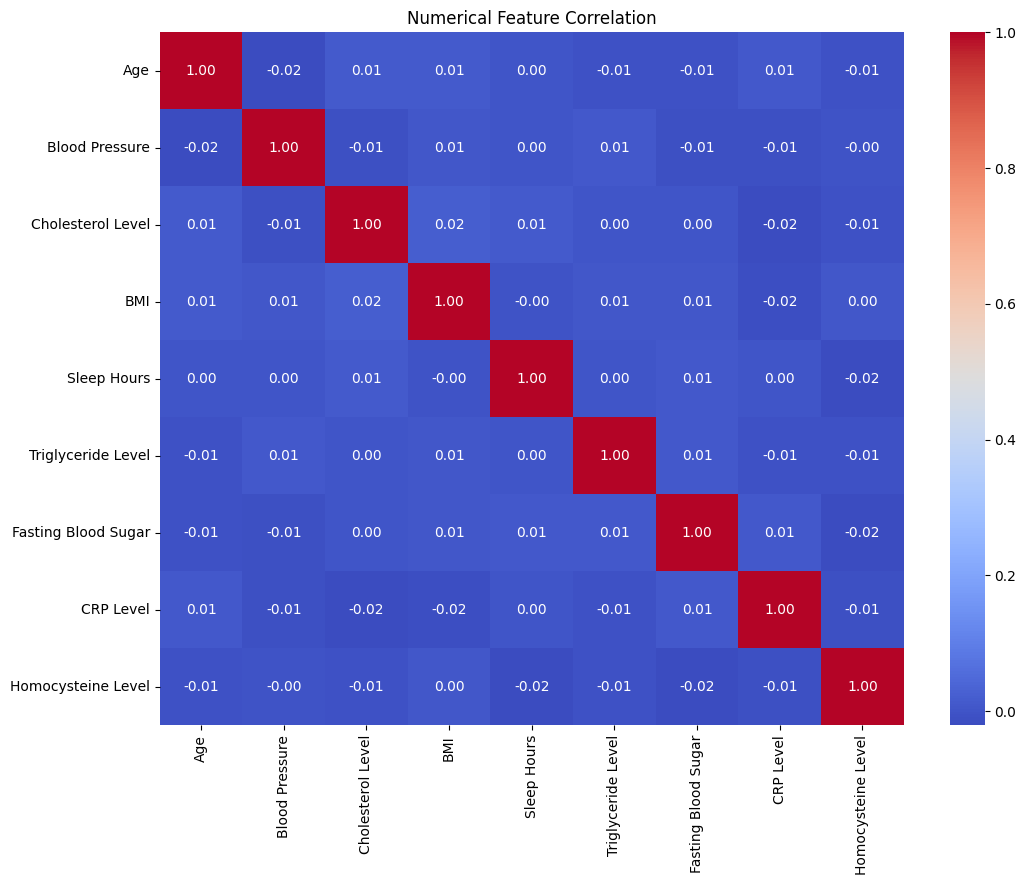

In [99]:
plt.figure(figsize=(12,9))

correlation = df[numerical_columns + [TARGET]].corr(
    numeric_only=True
)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlation")
plt.show()

In [100]:
X = df.drop(
    columns=[TARGET]
)

y = df[TARGET]

In [101]:
print("X:", X.shape)
print("y:", y.shape)

X: (10000, 20)
y: (10000,)


In [102]:
print(y.unique())

['No' 'Yes']


In [103]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [104]:
print(y.value_counts())

Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


In [105]:
if y.dtype == "object":

    target_mapping = {
        "No": 0,
        "Yes": 1
    }

    y = y.map(target_mapping)

print(y.unique())

[0 1]


In [106]:
from sklearn.model_selection import train_test_split

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 20)
Testing data: (2000, 20)


In [108]:
categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical:")
print(categorical_features)

print("\nNumerical:")
print(numerical_features)

Categorical:
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

Numerical:
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']


In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

In [110]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    )
])

In [111]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [112]:
preprocessor = ColumnTransformer([
    (
        "numerical",
        numeric_pipeline,
        numerical_features
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [113]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.svm import SVC

from xgboost import XGBClassifier

In [114]:
logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=2000
        )
    )
])

In [115]:
random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [116]:
extra_trees_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [117]:
gradient_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
])

In [118]:
xgb_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )
    )
])

In [119]:
svm_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",
        SVC(
            probability=True,
            random_state=42
        )
    )
])

In [120]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Extra Trees": extra_trees_model,
    "Gradient Boosting": gradient_model,
    "XGBoost": xgb_model,
    "SVM": svm_model
}

In [121]:
trained_models = {}

for name, model in models.items():

    print(
        f"\nTraining {name}..."
    )

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

print("\nAll models trained successfully.")


Training Logistic Regression...

Training Random Forest...

Training Extra Trees...

Training Gradient Boosting...

Training XGBoost...

Training SVM...

All models trained successfully.


In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in trained_models.items():

    y_pred = model.predict(
        X_test
    )

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Extra Trees,0.8000,0.500000,0.0025,0.004975,0.524895
5,SVM,0.8000,0.000000,0.0000,0.000000,0.516161
1,Random Forest,0.8000,0.000000,0.0000,0.000000,0.502876
4,XGBoost,0.8000,0.000000,0.0000,0.000000,0.495078
0,Logistic Regression,0.8000,0.000000,0.0000,0.000000,0.486303
3,Gradient Boosting,0.7995,0.333333,0.0025,0.004963,0.472116


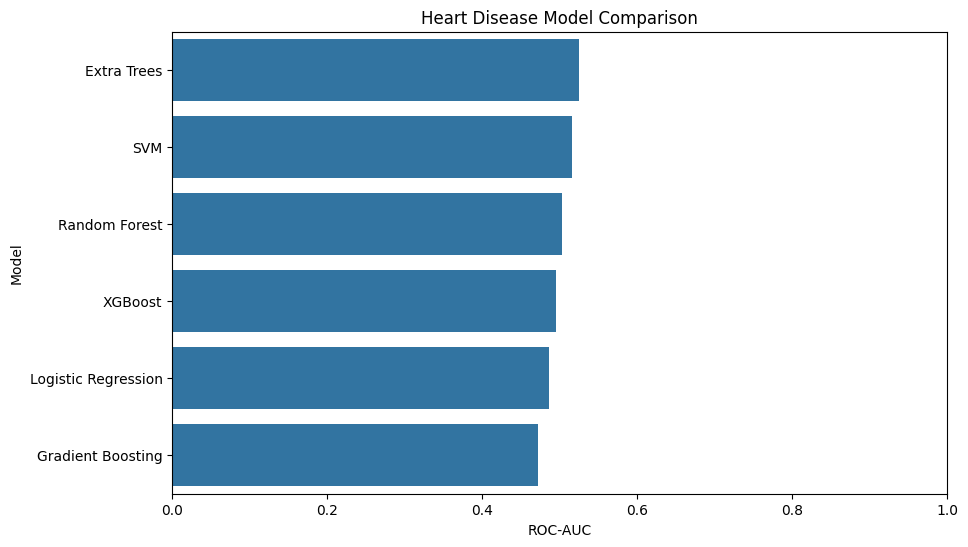

In [123]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="ROC-AUC",
    y="Model"
)

plt.title(
    "Heart Disease Model Comparison"
)

plt.xlim(0, 1)

plt.show()

In [124]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

In [125]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [126]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [127]:
cv_results = []

for name, model in models.items():

    print(
        f"Cross-validating {name}..."
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({

        "Model": name,

        "CV Accuracy": scores[
            "test_accuracy"
        ].mean(),

        "CV Precision": scores[
            "test_precision"
        ].mean(),

        "CV Recall": scores[
            "test_recall"
        ].mean(),

        "CV F1": scores[
            "test_f1"
        ].mean(),

        "CV ROC-AUC": scores[
            "test_roc_auc"
        ].mean()
    })

cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df = cv_results_df.sort_values(
    by="CV ROC-AUC",
    ascending=False
)

display(cv_results_df)

Cross-validating Logistic Regression...
Cross-validating Random Forest...
Cross-validating Extra Trees...
Cross-validating Gradient Boosting...
Cross-validating XGBoost...
Cross-validating SVM...


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
5,SVM,0.800000,0.000000,0.00000,0.000000,0.512693
0,Logistic Regression,0.800000,0.000000,0.00000,0.000000,0.511522
1,Random Forest,0.800000,0.000000,0.00000,0.000000,0.505958
4,XGBoost,0.799625,0.000000,0.00000,0.000000,0.505239
2,Extra Trees,0.799250,0.133333,0.00125,0.002477,0.504499
3,Gradient Boosting,0.798875,0.266667,0.00250,0.004946,0.501092


In [128]:
best_model_name = (
    cv_results_df
    .sort_values(
        "CV ROC-AUC",
        ascending=False
    )
    .iloc[0]["Model"]
)

print(
    "Best Model:",
    best_model_name
)

Best Model: SVM


In [129]:
best_model = models[
    best_model_name
]

In [130]:
best_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Blood Pressure',
                                                   'Cholesterol Level', 'BMI',
                                                   'Sleep Hours',
                                                   'Triglyceride Level',
                                                   'Fasting Blood Sugar',
                                                   'CRP Level',
                                                   'Homocysteine Level']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Exercise Habits',
                                                   'Smoking',
                                                   'Family Heart Disease',
                                                   'Diabetes',
                                                   'High Blood Pressure',
                                                   'Low HDL Cholesterol',
                                                   'High LDL Cholesterol',
                                                   'Alcohol Consumption',
                                                   'Stress Level',
                                                   'Sugar Consumption'])])),
                ('classifier', SVC(probability=True, random_state=42))])

In [131]:
y_pred = best_model.predict(
    X_test
)

y_prob = best_model.predict_proba(
    X_test
)[:, 1]

In [132]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.80      1.00      0.89      1600
   Heart Disease       0.00      0.00      0.00       400

        accuracy                           0.80      2000
       macro avg       0.40      0.50      0.44      2000
    weighted avg       0.64      0.80      0.71      2000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


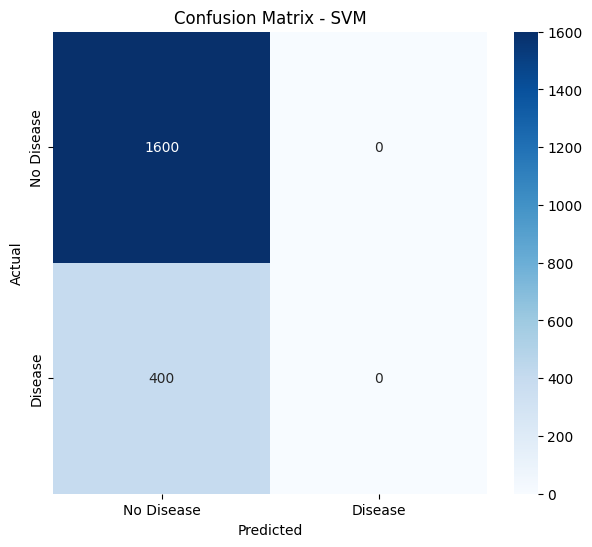

In [133]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Disease",
        "Disease"
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

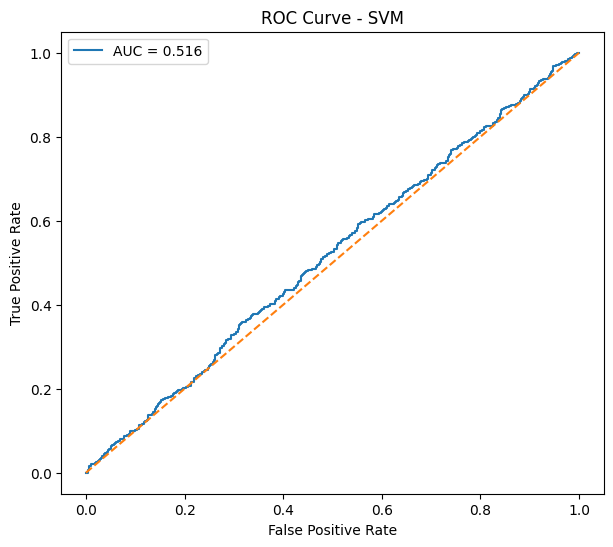

In [134]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.legend()

plt.show()

In [135]:
sample_patient = X_test.iloc[[0]]

display(sample_patient)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
6177,63.0,Male,130.0,234.0,High,Yes,No,Yes,38.078,Yes,No,Yes,Low,Low,8.860326,High,284.0,120.0,6.762998,15.550978


In [136]:
prediction = best_model.predict(
    sample_patient
)[0]

probability = best_model.predict_proba(
    sample_patient
)[0][1]

print(
    "Prediction:",
    prediction
)

print(
    f"Heart Disease Probability: "
    f"{probability * 100:.2f}%"
)

Prediction: 0
Heart Disease Probability: 20.04%


In [137]:
def predict_heart_disease(
    model,
    patient_data
):

    prediction = model.predict(
        patient_data
    )[0]

    probability = model.predict_proba(
        patient_data
    )[0][1]

    if probability < 0.30:
        risk = "Low"

    elif probability < 0.70:
        risk = "Moderate"

    else:
        risk = "High"

    result = {
        "prediction": int(prediction),
        "probability": round(
            float(probability),
            4
        ),
        "risk_level": risk
    }

    return result

In [138]:
result = predict_heart_disease(
    best_model,
    sample_patient
)

print(result)

{'prediction': 0, 'probability': 0.2004, 'risk_level': 'Low'}


In [139]:
model_path = "/content/heart_disease_model.pkl"

joblib.dump(
    best_model,
    model_path
)

print(
    "Saved:",
    model_path
)

Saved: /content/heart_disease_model.pkl
